In [88]:
import argparse
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from functools import partial
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '../../Models'))
from models.GANs import SimpleGANGenerator
from models.noise import get_noise_function
from models.utils import EHRDataset
from utils.helpers import MongoExtractor
from models.utils import load_checkpoint

import yaml
import sys
import os
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
from functools import partial


from utils.helpers import MongoExtractor
from models.GANs import SimpleGANGenerator
from models.utils import EHRDataset
from train.train_cGAN_v1_1 import collate_fn, preprocess_data

from dotenv import load_dotenv

load_dotenv()


True

# Prognosis 

# ConditionalGAN

In [89]:
import torch
import numpy as np
import random
torch.cuda.empty_cache()



import argparse
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from functools import partial
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '../../Models'))
from models.GANs import SimpleGANGenerator
from models.noise import get_noise_function
from models.utils import EHRDataset
from utils.helpers import MongoExtractor
from models.utils import load_checkpoint

import yaml
import sys
import os
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
from functools import partial


from utils.helpers import MongoExtractor
from models.GANs import SimpleGANGenerator
from models.utils import EHRDataset
from train.train_cGAN_v1_1 import collate_fn, preprocess_data

from dotenv import load_dotenv

load_dotenv()


True

In [90]:
config_file = '../../Models/configs/config_v1_1.yaml'
model_checkpoint = '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-16_16-49-30_epochs_500_bs_64_lrgen_0.0005_lrdisc_0.0002_latent_6_optgen_adam_optdisc_adam_noise_uniform_criterion_MSELoss/checkpoints/generator_epoch_499.pth'
validation_data_config = '../../Models/configs/config_v1_1_val.yaml'

In [91]:
def inference(generator, data_loader, noise_function, device):
    generator.eval()
    

    results = []
    real_features_list = []
    labels_list = []
    with torch.no_grad():
    

        for features, labels in data_loader:
            real_features = features
    

            # Generate noise for inference
            # noise = noise_function(real_features.size(0), device)
       
            # Concatenate features and noise
            generator_input = torch.cat((real_features, noise_function), dim=1)

            # Generate fake labels using the generator
            fake_labels = generator(generator_input)

            # Collect results
            results.append(fake_labels.cpu().numpy())
            real_features_list.append(real_features.cpu().numpy())
            labels_list.append(labels-1)

    return np.argmax(np.vstack(results), axis=1), np.vstack(labels_list).flatten().astype(int), real_features_list, np.vstack(results)
config = MongoExtractor.load_config(config_file)

# Extract data configuration
dc = config['data_config']

# Load training data
mongo_extractor_train = MongoExtractor(
    connection_string=os.getenv('MONGO_URI'),
    database_name=os.getenv('MONGO_DB'),
    collection_name=os.getenv('MONGO_COLLECTION'),
    config_file=config_file
)
df = mongo_extractor_train.get_dataframe()

# Load validation data
mongo_extractor_val = MongoExtractor(
    connection_string=os.getenv('MONGO_URI'),
    database_name=os.getenv('MONGO_DB'),
    collection_name=os.getenv('MONGO_COLLECTION'),
    config_file=validation_data_config
)
df_val= mongo_extractor_val.get_dataframe()
df_val_original = mongo_extractor_val.get_dataframe()

dc = config['data_config']
mc = config['model_config']
sgc = config['simplegan_config']
mc['latent_dim'] = 6
mc['noise_type'] = 'uniform'
mc['batch_size'] = 104

df, df_val, scaler, label_encoder = preprocess_data(df, df_val, dc)

dataset_train = EHRDataset(df)
dataset_val = EHRDataset(df_val)

collate_fn_dc = partial(collate_fn, dc=dc)
data_loader_val = DataLoader(dataset_val, batch_size=mc['batch_size'], drop_last=True, collate_fn=collate_fn_dc)


exclude = list(set(dc['exclude_fields']) - set(dc['labels']))
df = df.drop(columns=exclude)
df = df.drop(columns=dc['labels'])
sgc['input_dim'] = df.shape[1] 

# Load the generator model and optimizer

generator = SimpleGANGenerator(input_dim=sgc['input_dim'] + mc['latent_dim'], output_dim=sgc['output_dim'])

device = torch.device('cpu')
optimizer_gen = torch.optim.Adam(generator.parameters(), lr=0.0001)  # Use the same optimizer as during training
generator, optimizer_gen, _, _ = load_checkpoint(model_checkpoint, generator, optimizer_gen)
torch.manual_seed(43)
noise_function = get_noise_function(mc)

Checkpoint loaded from /home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-16_16-49-30_epochs_500_bs_64_lrgen_0.0005_lrdisc_0.0002_latent_6_optgen_adam_optdisc_adam_noise_uniform_criterion_MSELoss/checkpoints/generator_epoch_499.pth


In [92]:
torch.manual_seed(43)
noise_function = get_noise_function(mc)
categorical_fields = list(set(dc['categorical_fields']) - set(dc['exclude_fields']))
all_features = df.columns.tolist()
numerical_fields = list(set(all_features) - set(categorical_fields) - set(dc['exclude_fields']))
pred_labels, real_labels, features, pred_prob = inference(generator, data_loader_val, noise_function, device)
pred_labels, real_labels, features, pred_prob

(array([1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
        1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
        1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0]),
 array([0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
        0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
        0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
        0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0]),
 [array([[0.08273381, 0.18345323, 0.19433199, ..., 0.        , 0.        ,
          1.        ],
         [       nan,        nan,        nan, ..., 0.        , 0.        ,
          1.        ],
         [       nan,        nan,        nan, ..., 0.        , 1.        ,
          0.        ]

In [93]:
# Convert Tensors to DataFrame

# Convert tensors to a list of lists
features= np.array(features)
features_reshaped = features.reshape(-1, features.shape[-1])

column_names = ['size_a', 'size_b', 'size_c', 'age_admission', 'male', 'female', 'group_B', 'group_D', 'group_S', 'metastasis_no', 'metastasis_si', 'intermediat', 'malign']

# Create DataFrame
df_validation = pd.DataFrame(features_reshaped, columns=column_names)


# Display the DataFrame
df_validation[[ 'size_a', 'size_b', 'size_c', 'age_admission' ]] = scaler.inverse_transform(df_validation[[ 'size_a', 'size_b', 'size_c', 'age_admission' ]])
df_validation['real_labels'] = real_labels
df_validation['predicted_labels'] = pred_labels

df_validation

,size_a,size_b,size_c,age_admission,male,female,group_B,group_D,group_S,metastasis_no,metastasis_si,intermediat,malign,real_labels,predicted_labels
0,94.999992,53.000000,51.000000,55.000004,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0,1
1,NaN,NaN,NaN,79.000000,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1,0
2,NaN,NaN,NaN,83.000000,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0
3,NaN,NaN,NaN,29.000000,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0,1
4,49.999996,39.000000,39.000000,35.000000,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,53.000000,47.000004,37.999996,17.000000,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0,0
100,17.999998,14.000000,12.000000,19.000002,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0,0
101,34.000000,14.999999,15.000001,47.000000,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1,0
102,65.000000,55.000004,35.000000,32.000000,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1,1


Accuracy: 0.60


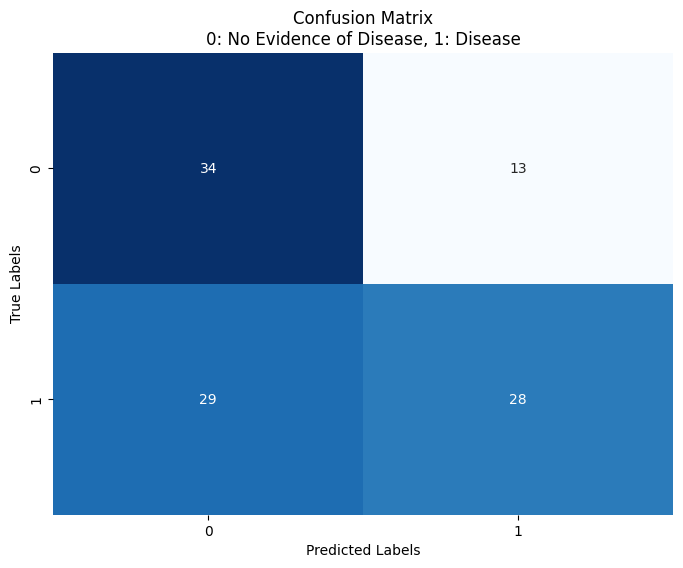

In [94]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt



# Compute confusion matrix
conf_matrix = confusion_matrix(df_validation['real_labels'], df_validation['predicted_labels'])
accuracy = accuracy_score(df_validation['real_labels'], df_validation['predicted_labels'])
print(f'Accuracy: {accuracy:.2f}')
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix\n0: No Evidence of Disease, 1: Disease')
plt.show()


/tmp/ipykernel_12959/2340108709.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_accuracy = df_clean.groupby('age_group')['correct_model_prediction'].mean() * 100
/tmp/ipykernel_12959/2340108709.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  threshold_conditions = df_clean.groupby('age_group')['real_labels'].agg(lambda x: x.mode()[0])
/tmp/ipykernel_12959/2340108709.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence th

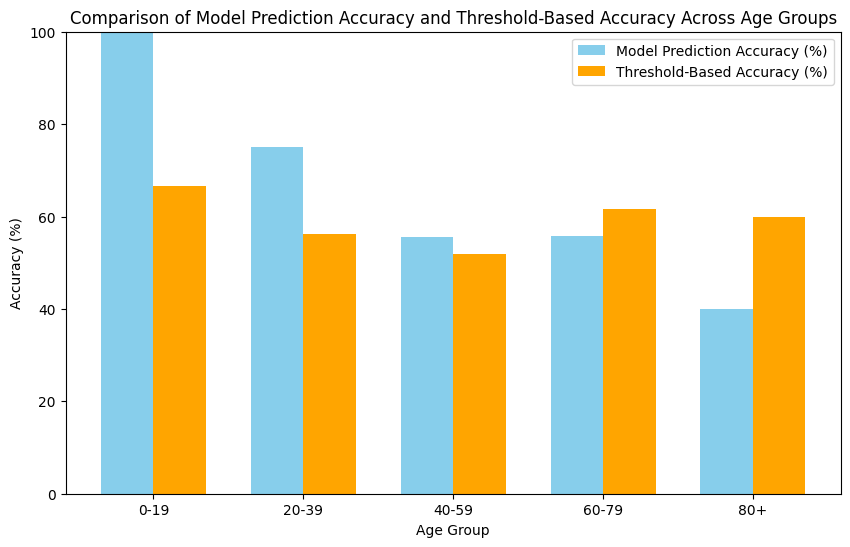

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Define age intervals including 0-19
age_bins = [0, 20, 40, 60, 80, 100]
age_labels = ['0-19', '20-39', '40-59', '60-79', '80+']
df_validation['age_group'] = pd.cut(df_validation['age_admission'], bins=age_bins, labels=age_labels, right=False)

# Drop rows with NaN in real_labels or predicted_labels for calculation
df_clean = df_validation.dropna(subset=['real_labels', 'predicted_labels'])

# Model-based prediction accuracy by age group
df_clean['correct_model_prediction'] = df_clean['real_labels'] == df_clean['predicted_labels']
model_accuracy = df_clean.groupby('age_group')['correct_model_prediction'].mean() * 100

# Define threshold predictions based on the mode of real_labels in each age group
threshold_conditions = df_clean.groupby('age_group')['real_labels'].agg(lambda x: x.mode()[0])
df_clean['threshold_prediction'] = df_clean['age_group'].map(threshold_conditions)
df_clean['correct_threshold_prediction'] = df_clean['real_labels'] == df_clean['threshold_prediction']
threshold_accuracy = df_clean.groupby('age_group')['correct_threshold_prediction'].mean() * 100

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Bar width
bar_width = 0.35
index = np.arange(len(age_labels))

# Model accuracy bars
bar1 = ax.bar(index, model_accuracy, bar_width, label='Model Prediction Accuracy (%)', color='skyblue')

# Threshold accuracy bars
bar2 = ax.bar(index + bar_width, threshold_accuracy, bar_width, label='Threshold-Based Accuracy (%)', color='orange')

# Labels and titles
ax.set_xlabel('Age Group')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparison of Model Prediction Accuracy and Threshold-Based Accuracy Across Age Groups')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(age_labels)
ax.set_ylim(0, 100)

# Add legend
ax.legend()

plt.show()

Brier Score - GAN (Median): 0.2809307937996489
Log Loss - GAN (Median): 0.8805318926376239
AUC-ROC - GAN (Median): 0.635311683463979
Precision - GAN (Median): 0.6829268292682927
Recall - GAN (Median): 0.49122807017543857
F1 Score - GAN (Median): 0.5714285714285714
Accuracy - GAN (Median): 0.5961538461538461


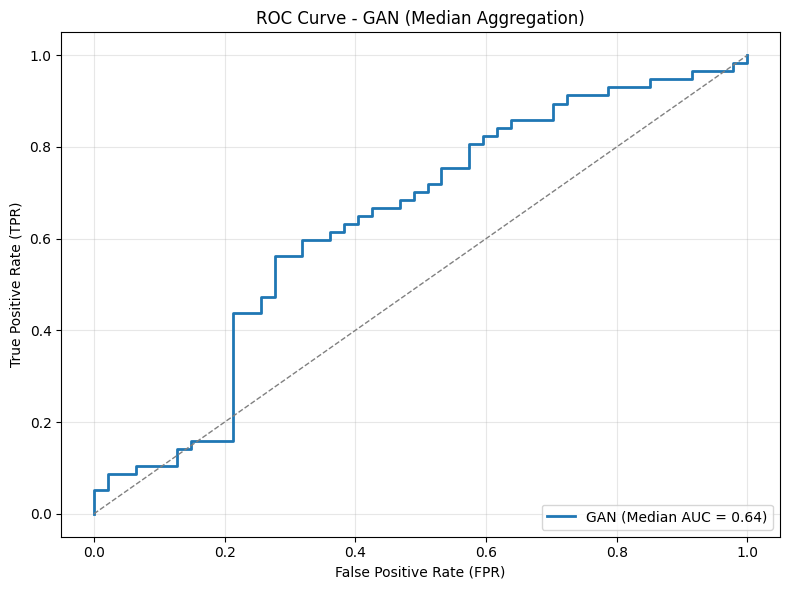

In [96]:
import numpy as np
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    accuracy_score
)
import matplotlib.pyplot as plt
import torch

def aggregate_inference(generator, data_loader, num_samples, device):
    pred_probs = []
    for _ in range(num_samples):
        noise_function = get_noise_function(mc)
        # Generate predictions with new noise each time
        pred_labels, real_labels, features, pred_prob = inference(generator, data_loader, noise_function, device)
        pred_probs.append(pred_prob)
    return np.array(pred_probs), real_labels

# Simulated inputs (replace these with real outputs)
num_samples = 100  # Number of runs per data point with different noise
device = torch.device("cpu")  # Simulated GAN predictions

# Run aggregated inference
pred_probs_samples, real_labels = aggregate_inference(generator, data_loader_val, num_samples, device)

# Aggregate probabilities (median)
pred_probs_median = np.median(pred_probs_samples, axis=0)
pred_probs_median = pred_probs_median / np.sum(pred_probs_median, axis=1, keepdims=True)
# Brier Score
brier_gan = brier_score_loss(real_labels, pred_probs_median[:, 1])

# Log Loss
log_loss_gan = log_loss(real_labels, pred_probs_median[:, 1])

# AUC-ROC Score
auc_roc_gan = roc_auc_score(real_labels, pred_probs_median[:, 1])

# Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
gan_predictions = np.argmax(np.vstack(pred_probs_median), axis=1)

# Precision, Recall, F1 Score
precision_gan = precision_score(real_labels, gan_predictions)
recall_gan = recall_score(real_labels, gan_predictions)
f1_gan = f1_score(real_labels, gan_predictions)

# Accuracy
accuracy_gan = accuracy_score(real_labels, gan_predictions)

# Print metrics
print("Brier Score - GAN (Median):", brier_gan)
print("Log Loss - GAN (Median):", log_loss_gan)
print("AUC-ROC - GAN (Median):", auc_roc_gan)
print("Precision - GAN (Median):", precision_gan)
print("Recall - GAN (Median):", recall_gan)
print("F1 Score - GAN (Median):", f1_gan)
print("Accuracy - GAN (Median):", accuracy_gan)

# Plot ROC Curve
fpr_gan, tpr_gan, _ = roc_curve(real_labels, pred_probs_median[:, 1])
roc_auc_gan = auc(fpr_gan, tpr_gan)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gan, tpr_gan, label=f'GAN (Median AUC = {roc_auc_gan:.2f})', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.title('ROC Curve - GAN (Median Aggregation)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pred_probs_median_cgan = pred_probs_median.copy()


# Wasserstaing GAN

In [97]:
import torch
import numpy as np
import random
torch.cuda.empty_cache()



import argparse
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from functools import partial
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '../../Models'))
from models.GANs import SimpleGANGenerator
from models.noise import get_noise_function
from models.utils import EHRDataset
from utils.helpers import MongoExtractor
from models.utils import load_checkpoint

import yaml
import sys
import os
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
from functools import partial


from utils.helpers import MongoExtractor
from models.GANs import SimpleGANGenerator
from models.utils import EHRDataset
from train.train_wGAN_v1_1 import collate_fn, preprocess_data

from dotenv import load_dotenv

load_dotenv()


True

In [98]:
config_file = '../../Models/configs/config_v1_1.yaml'
model_checkpoint = '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-16_18-27-05_epochs_1000_bs_64_lrgen_0.001_lrdisc_0.0001_latent_4_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss/checkpoints/generator_final.pth'
#'/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-16_17-40-26_epochs_500_bs_64_lrgen_0.001_lrdisc_0.0002_latent_4_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss/checkpoints/generator_final.pth'
validation_data_config = '../../Models/configs/config_v1_1_val.yaml'

In [99]:
def inference(generator, data_loader, noise_function, device):
    generator.eval()
    

    results = []
    real_features_list = []
    labels_list = []
    with torch.no_grad():
    

        for features, labels in data_loader:
            real_features = features
    

            # Generate noise for inference
            # noise = noise_function(real_features.size(0), device)
       
            # Concatenate features and noise
            generator_input = torch.cat((real_features, noise_function), dim=1)

            # Generate fake labels using the generator
            fake_labels = generator(generator_input)

            # Collect results
            results.append(fake_labels.cpu().numpy())
            real_features_list.append(real_features.cpu().numpy())
            labels_list.append(labels-1)

    return np.argmax(np.vstack(results), axis=1), np.vstack(labels_list).flatten().astype(int), real_features_list, np.vstack(results)

config = MongoExtractor.load_config(config_file)

# Extract data configuration
dc = config['data_config']

# Load training data
mongo_extractor_train = MongoExtractor(
    connection_string=os.getenv('MONGO_URI'),
    database_name=os.getenv('MONGO_DB'),
    collection_name=os.getenv('MONGO_COLLECTION'),
    config_file=config_file
)
df = mongo_extractor_train.get_dataframe()

# Load validation data
mongo_extractor_val = MongoExtractor(
    connection_string=os.getenv('MONGO_URI'),
    database_name=os.getenv('MONGO_DB'),
    collection_name=os.getenv('MONGO_COLLECTION'),
    config_file=validation_data_config
)
df_val= mongo_extractor_val.get_dataframe()
df_val_original = mongo_extractor_val.get_dataframe()

dc = config['data_config']
mc = config['model_config']
sgc = config['simplegan_config']
mc['latent_dim'] = 4
mc['noise_type'] = 'gaussian'
mc['batch_size'] = 104

df, df_val, scaler, label_encoder = preprocess_data(df, df_val, dc)

dataset_train = EHRDataset(df)
dataset_val = EHRDataset(df_val)

collate_fn_dc = partial(collate_fn, dc=dc)
data_loader_val = DataLoader(dataset_val, batch_size=mc['batch_size'], drop_last=True, collate_fn=collate_fn_dc)


exclude = list(set(dc['exclude_fields']) - set(dc['labels']))
df = df.drop(columns=exclude)
df = df.drop(columns=dc['labels'])
sgc['input_dim'] = df.shape[1] 

# Load the generator model and optimizer

generator = SimpleGANGenerator(input_dim=sgc['input_dim'] + mc['latent_dim'], output_dim=sgc['output_dim'])

device = torch.device('cpu')
optimizer_gen = torch.optim.Adam(generator.parameters(), lr=0.0001)  # Use the same optimizer as during training
generator, optimizer_gen, _, _ = load_checkpoint(model_checkpoint, generator, optimizer_gen)
torch.manual_seed(43)
noise_function = get_noise_function(mc)


Checkpoint loaded from /home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-16_18-27-05_epochs_1000_bs_64_lrgen_0.001_lrdisc_0.0001_latent_4_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss/checkpoints/generator_final.pth


In [100]:
categorical_fields = list(set(dc['categorical_fields']) - set(dc['exclude_fields']))
all_features = df.columns.tolist()
numerical_fields = list(set(all_features) - set(categorical_fields) - set(dc['exclude_fields']))
pred_labels, real_labels, features, pred_prob = inference(generator, data_loader_val, noise_function, device)

In [101]:
# Convert Tensors to DataFrame

# Convert tensors to a list of lists
features= np.array(features)
features_reshaped = features.reshape(-1, features.shape[-1])

column_names = ['size_a', 'size_b', 'size_c', 'age_admission', 'male', 'female', 'group_B', 'group_D', 'group_S', 'metastasis_no', 'metastasis_si', 'intermediat', 'malign']

# Create DataFrame
df_validation = pd.DataFrame(features_reshaped, columns=column_names)


# Display the DataFrame
df_validation[[ 'size_a', 'size_b', 'size_c', 'age_admission' ]] = scaler.inverse_transform(df_validation[[ 'size_a', 'size_b', 'size_c', 'age_admission' ]])
df_validation['real_labels'] = real_labels
df_validation['predicted_labels'] = pred_labels


Accuracy: 0.57


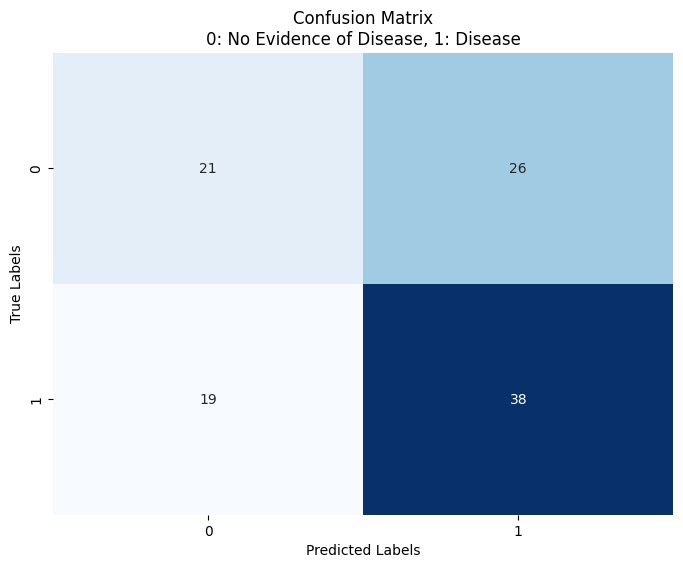

In [102]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt



# Compute confusion matrix
conf_matrix = confusion_matrix(df_validation['real_labels'], df_validation['predicted_labels'])
accuracy = accuracy_score(df_validation['real_labels'], df_validation['predicted_labels'])
print(f'Accuracy: {accuracy:.2f}')
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix\n0: No Evidence of Disease, 1: Disease')
plt.show()

/tmp/ipykernel_12959/1884798091.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_accuracy = df_clean.groupby('age_group')['correct_model_prediction'].mean() * 100
/tmp/ipykernel_12959/1884798091.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  threshold_conditions = df_clean.groupby('age_group')['real_labels'].agg(lambda x: x.mode()[0])
/tmp/ipykernel_12959/1884798091.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence th

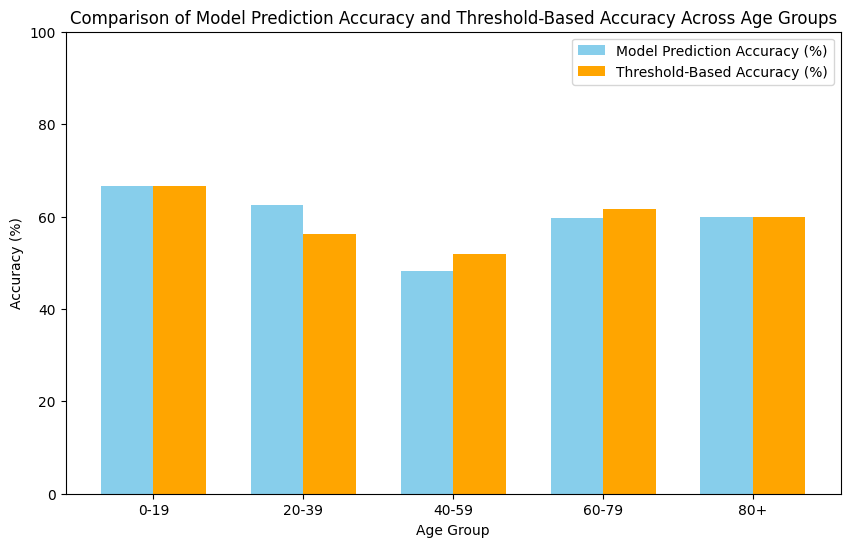

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Define age intervals including 0-19
age_bins = [0, 20, 40, 60, 80, 100]
age_labels = ['0-19', '20-39', '40-59', '60-79', '80+']
df_validation['age_group'] = pd.cut(df_validation['age_admission'], bins=age_bins, labels=age_labels, right=False)

# Drop rows with NaN in real_labels or predicted_labels for calculation
df_clean = df_validation.dropna(subset=['real_labels', 'predicted_labels'])

# Model-based prediction accuracy by age group
df_clean['correct_model_prediction'] = df_clean['real_labels'] == df_clean['predicted_labels']
model_accuracy = df_clean.groupby('age_group')['correct_model_prediction'].mean() * 100

# Define threshold predictions based on the mode of real_labels in each age group
threshold_conditions = df_clean.groupby('age_group')['real_labels'].agg(lambda x: x.mode()[0])
df_clean['threshold_prediction'] = df_clean['age_group'].map(threshold_conditions)
df_clean['correct_threshold_prediction'] = df_clean['real_labels'] == df_clean['threshold_prediction']
threshold_accuracy = df_clean.groupby('age_group')['correct_threshold_prediction'].mean() * 100

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Bar width
bar_width = 0.35
index = np.arange(len(age_labels))

# Model accuracy bars
bar1 = ax.bar(index, model_accuracy, bar_width, label='Model Prediction Accuracy (%)', color='skyblue')

# Threshold accuracy bars
bar2 = ax.bar(index + bar_width, threshold_accuracy, bar_width, label='Threshold-Based Accuracy (%)', color='orange')

# Labels and titles
ax.set_xlabel('Age Group')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparison of Model Prediction Accuracy and Threshold-Based Accuracy Across Age Groups')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(age_labels)
ax.set_ylim(0, 100)

# Add legend
ax.legend()

Brier Score - GAN (Median): 0.4240258058624088
Log Loss - GAN (Median): 2.060586401046924
AUC-ROC - GAN (Median): 0.6257932064203061
Precision - GAN (Median): 0.59375
Recall - GAN (Median): 0.6666666666666666
F1 Score - GAN (Median): 0.628099173553719
Accuracy - GAN (Median): 0.5673076923076923


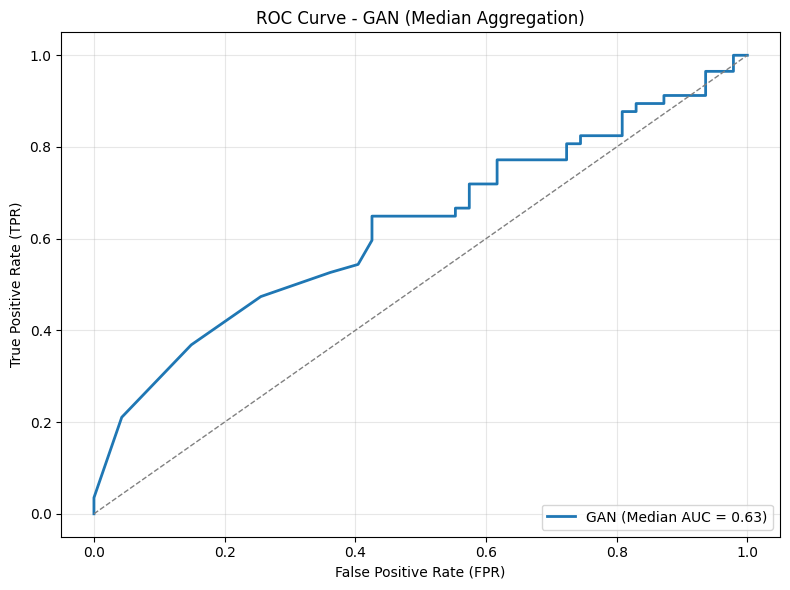

In [104]:
import numpy as np
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    accuracy_score
)
import matplotlib.pyplot as plt
import torch

def aggregate_inference(generator, data_loader, num_samples, device):
    pred_probs = []
    for _ in range(num_samples):
        noise_function = get_noise_function(mc)
        # Generate predictions with new noise each time
        pred_labels, real_labels, features, pred_prob = inference(generator, data_loader, noise_function, device)
        pred_probs.append(pred_prob)
    return np.array(pred_probs), real_labels

# Simulated inputs (replace these with real outputs)
num_samples = 100  # Number of runs per data point with different noise
device = torch.device("cpu")  # Simulated GAN predictions

# Run aggregated inference
pred_probs_samples, real_labels = aggregate_inference(generator, data_loader_val, num_samples, device)

# Aggregate probabilities (median)
pred_probs_median = np.median(pred_probs_samples, axis=0)
pred_probs_median = pred_probs_median / np.sum(pred_probs_median, axis=1, keepdims=True)
# Brier Score
brier_gan = brier_score_loss(real_labels, pred_probs_median[:, 1])

# Log Loss
log_loss_gan = log_loss(real_labels, pred_probs_median[:, 1])

# AUC-ROC Score
auc_roc_gan = roc_auc_score(real_labels, pred_probs_median[:, 1])

# Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
gan_predictions = np.argmax(np.vstack(pred_probs_median), axis=1)

# Precision, Recall, F1 Score
precision_gan = precision_score(real_labels, gan_predictions)
recall_gan = recall_score(real_labels, gan_predictions)
f1_gan = f1_score(real_labels, gan_predictions)

# Accuracy
accuracy_gan = accuracy_score(real_labels, gan_predictions)

# Print metrics
print("Brier Score - GAN (Median):", brier_gan)
print("Log Loss - GAN (Median):", log_loss_gan)
print("AUC-ROC - GAN (Median):", auc_roc_gan)
print("Precision - GAN (Median):", precision_gan)
print("Recall - GAN (Median):", recall_gan)
print("F1 Score - GAN (Median):", f1_gan)
print("Accuracy - GAN (Median):", accuracy_gan)

# Plot ROC Curve
fpr_gan, tpr_gan, _ = roc_curve(real_labels, pred_probs_median[:, 1])
roc_auc_gan = auc(fpr_gan, tpr_gan)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gan, tpr_gan, label=f'GAN (Median AUC = {roc_auc_gan:.2f})', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.title('ROC Curve - GAN (Median Aggregation)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pred_probs_median_wgan = pred_probs_median.copy()


# DNN

In [105]:
import torch
import numpy as np
import random
torch.cuda.empty_cache()



import argparse
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from functools import partial
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '../../Models'))
from models.GANs import SimpleGANGenerator
from models.noise import get_noise_function
from models.utils import EHRDataset
from utils.helpers import MongoExtractor
from models.utils import load_checkpoint

import yaml
import sys
import os
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
from functools import partial


from utils.helpers import MongoExtractor
from models.GANs import SimpleGANGenerator
from models.utils import EHRDataset
from train.train_DNN_v1_1 import collate_fn, preprocess_data

from dotenv import load_dotenv

load_dotenv()


True

In [106]:
config_file = '/home/andrea/Desktop/Sarcoma-DT/Models/configs/config_v1_1.yaml'
model_checkpoint = '/home/andrea/Desktop/StoreModels/DNN_v_1_1/checkpoints/generator.pth'
validation_data_config = '/home/andrea/Desktop/Sarcoma-DT/Models/configs/config_v1_1_val.yaml'


In [107]:
def inference(generator, data_loader, device):
    generator.eval()

    results = []
    real_features_list = []
    labels_list = []
    with torch.no_grad():

        for features, labels in data_loader:
            real_features = features

            # Generate noise for inference
            # noise = noise_function(real_features.size(0), device)
       
            # Concatenate features and noise
            generator_input = real_features

            # Generate fake labels using the generator
            fake_labels = generator(generator_input)

            # Collect results
            results.append(fake_labels.cpu().numpy())
            real_features_list.append(real_features.cpu().numpy())
            labels_list.append(labels-1)

    return np.argmax(np.vstack(results), axis=1), np.vstack(labels_list).flatten().astype(int), real_features_list, np.vstack(results)
config = MongoExtractor.load_config(config_file)

# Extract data configuration
dc = config['data_config']

# Load training data
mongo_extractor_train = MongoExtractor(
    connection_string=os.getenv('MONGO_URI'),
    database_name=os.getenv('MONGO_DB'),
    collection_name=os.getenv('MONGO_COLLECTION'),
    config_file=config_file
)
df = mongo_extractor_train.get_dataframe()

# Load validation data
mongo_extractor_val = MongoExtractor(
    connection_string=os.getenv('MONGO_URI'),
    database_name=os.getenv('MONGO_DB'),
    collection_name=os.getenv('MONGO_COLLECTION'),
    config_file=validation_data_config
)
df_val= mongo_extractor_val.get_dataframe()
df_val_original = mongo_extractor_val.get_dataframe()

dc = config['data_config']
mc = config['model_config']
sgc = config['simplegan_config']
mc['latent_dim'] = 0
mc['noise_type'] = 'uniform'
mc['batch_size'] = 104

df, df_val, scaler, label_encoder = preprocess_data(df, df_val, dc)

dataset_train = EHRDataset(df)
dataset_val = EHRDataset(df_val)

collate_fn_dc = partial(collate_fn, dc=dc)
data_loader_val = DataLoader(dataset_val, batch_size=mc['batch_size'], drop_last=True, collate_fn=collate_fn_dc)


exclude = list(set(dc['exclude_fields']) - set(dc['labels']))
df = df.drop(columns=exclude)
df = df.drop(columns=dc['labels'])
sgc['input_dim'] = df.shape[1] 

# Load the generator model and optimizer

generator = SimpleGANGenerator(input_dim=sgc['input_dim'] + mc['latent_dim'], output_dim=sgc['output_dim'])

device = torch.device('cpu')
optimizer_gen = torch.optim.Adam(generator.parameters(), lr=0.0001)  # Use the same optimizer as during training
generator, optimizer_gen, _, _ = load_checkpoint(model_checkpoint, generator, optimizer_gen)

Checkpoint loaded from /home/andrea/Desktop/StoreModels/DNN_v_1_1/checkpoints/generator.pth


In [108]:
categorical_fields = list(set(dc['categorical_fields']) - set(dc['exclude_fields']))
all_features = df.columns.tolist()
numerical_fields = list(set(all_features) - set(categorical_fields) - set(dc['exclude_fields']))
pred_labels, real_labels, features, pred_prob = inference(generator, data_loader_val, device)


In [109]:
pred_prob


array([[0.6862036 , 0.2574719 ],
       [0.20775017, 0.7437602 ],
       [0.3403316 , 0.64791816],
       [0.7179962 , 0.31221116],
       [0.07488332, 0.83419955],
       [0.66383153, 0.3622601 ],
       [0.42454317, 0.6456707 ],
       [0.62833095, 0.5490343 ],
       [0.8083708 , 0.21968605],
       [0.77877647, 0.34252214],
       [0.5490689 , 0.53371006],
       [0.48228788, 0.51739997],
       [0.4462654 , 0.6479008 ],
       [0.25844434, 0.74348325],
       [0.19923769, 0.7589606 ],
       [0.18267766, 0.77307   ],
       [0.86978   , 0.15239164],
       [0.2945214 , 0.6935168 ],
       [0.23517385, 0.683764  ],
       [0.42963794, 0.53159773],
       [0.38771772, 0.63830596],
       [0.86717737, 0.07881576],
       [0.47598794, 0.59591943],
       [0.56234574, 0.45991966],
       [0.6657496 , 0.35676292],
       [0.6809875 , 0.33565816],
       [0.19528565, 0.8035698 ],
       [0.31615075, 0.68525755],
       [0.5245692 , 0.47115093],
       [0.29071727, 0.7710054 ],
       [0.

In [110]:
features= np.array(features)
features_reshaped = features.reshape(-1, features.shape[-1])

column_names = ['size_a', 'size_b', 'size_c', 'age_admission', 'male', 'female', 'group_B', 'group_D', 'group_S', 'metastasis_no', 'metastasis_si', 'intermediat', 'malign']

# Create DataFrame
df_validation = pd.DataFrame(features_reshaped, columns=column_names)


# Display the DataFrame
df_validation[['size_a', 'size_b', 'size_c', 'age_admission' ]] = scaler.inverse_transform(df_validation[[ 'size_a', 'size_b', 'size_c', 'age_admission' ]])
df_validation['real_labels'] = real_labels
df_validation['predicted_labels'] = pred_labels
df_validation[['no_disease', 'yes_disease']] = pred_prob
df_validation

,size_a,size_b,size_c,age_admission,male,female,group_B,group_D,group_S,metastasis_no,metastasis_si,intermediat,malign,real_labels,predicted_labels,no_disease,yes_disease
0,94.999992,53.000000,51.000000,55.000004,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0,0,0.686204,0.257472
1,NaN,NaN,NaN,79.000000,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1,1,0.207750,0.743760
2,NaN,NaN,NaN,83.000000,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,1,0.340332,0.647918
3,NaN,NaN,NaN,29.000000,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0,0,0.717996,0.312211
4,49.999996,39.000000,39.000000,35.000000,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1,1,0.074883,0.834200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,53.000000,47.000004,37.999996,17.000000,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0,0,0.930026,0.126831
100,17.999998,14.000000,12.000000,19.000002,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0,0,0.850374,0.158944
101,34.000000,14.999999,15.000001,47.000000,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1,0,0.850351,0.212671
102,65.000000,55.000004,35.000000,32.000000,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1,0,0.543814,0.460724


In [111]:


# Function to determine tumor/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_09-26-05_epochs_1000_bs_64_lrgen_0.002_lrdisc_0.0002_latent_12_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss/checkpoints/generator_final.pth size stage based on largest size in cm
def determine_size_stage(max_size_cm):
    if max_size_cm <= 5:
        return "T1"  # ≤ 5 cm
    elif max_size_cm <= 10:
        return "T2"  # > 5 cm and ≤ 10 cm
    elif max_size_cm <= 15:
        return "T3"  # > 10 cm and ≤ 15 cm
    elif max_size_cm > 15:
        return "T4"  # > 10 cm and ≤ 15 cm
    else:
        return "T0"  # > 15 cm


# Function to determine grade based on malignancy indicators
def determine_grade(row):
    if row['treatment_features.grading_3.0'] > 0:
        return "G3"  # High grade
    elif row['treatment_features.grading_1.0'] > 0:
        return "G1"
    elif row['treatment_features.grading_2.0'] > 0:
        return "G2"  # Intermediate grade
    else:
        return "G2"
    # if False:
    #     return "G2"
    # else:
    #     return "G1"  # Low grade

def assign_stage(row):
    max_size_cm = calculate_largest_size(row)
    size_stage = determine_size_stage(max_size_cm)
    metastasis_stage = determine_metastasis_stage(row)
    grade = determine_grade(row)
    
    if metastasis_stage == "M1":
        stage, prob = "Stage IV", 0.124  # 12.4% OS for Stage IV (M1)
    elif grade == "G1" and size_stage == "T1" and metastasis_stage == "M0":
        stage, prob = "Stage IA", 0.853  # Updated ~95% OS for Stage IA
    elif grade == "G1" and size_stage in ["T0","T2", "T3", "T4"] and metastasis_stage == "M0":
        stage, prob = "Stage IB", 0.830  # Updated ~85% OS for Stage IB
    elif grade in ["G2", "G3"]  and size_stage in ["T0", "T1"] and metastasis_stage == "M0":
        stage, prob = "Stage II", 0.79  # Updated ~75% OS for Stage IIA
    elif grade in ["G2", "G3"]  and size_stage in [ "T2"] and metastasis_stage == "M0":
        stage, prob = "Stage IIIA", 0.624  # Updated ~75% OS for Stage IIA
    elif grade in ["G2", "G3"]   and size_stage in ["T3", "T4"] and metastasis_stage == "M0":
        stage, prob = "Stage IIIB", 0.501 # Updated ~45% OS for Stage IIIB
    else:
        stage, prob = "Unknown Stage", 0.0  # Default for unclassified stages
    
    # Calculate the difference between staging probability and actual outcome
    outcome_diff = abs(1- prob)
    
    return stage, prob, outcome_diff


def calculate_largest_size(row):
    # Get the largest size in mm, then convert to cm
    max_size_mm = max(row['size_a'], row['size_b'], row['size_c'])
    max_size_cm = max_size_mm / 10  # Convert mm to cm
    return max_size_cm



# Function to determine metastasis stage
def determine_metastasis_stage(row):
    return "M1" if row['metastasis_si'] > 0 else "M0"

# Function to determine grade based on malignancy indicators
def determine_grade(row):
    if row['malign'] > 0:
        return "G3"  # High grade
    elif row['intermediat'] > 0:
        return "G2"  # Intermediate grade
    else:
        return "G1"  # Low grade

def assign_stage(row):
    max_size_cm = calculate_largest_size(row)
    size_stage = determine_size_stage(max_size_cm)
    metastasis_stage = determine_metastasis_stage(row)
    grade = determine_grade(row)
    
    # Stage assignment and OS probability based on refined AJCC logic and provided probabilities
    if metastasis_stage == "M1":
        stage, prob = "Stage IV", 0.124  # 12.4% OS for Stage IV (M1)
    elif grade == "G1" and metastasis_stage == "M0":
        stage, prob = "Stage I", 0.90  # Estimated ~90% OS for Stage I
    elif grade in ["G2", "G3"] and size_stage in ["T1", "T2"] and metastasis_stage == "M0":
        stage, prob = "Stage II", 0.70  # Estimated ~70% OS for Stage II
    elif grade == "G3" and size_stage in ["T3", "T4"] and metastasis_stage == "M0":
        stage, prob = "Stage III", 0.501  # 50.1% OS for Stage IIIB
    else:
        stage, prob = "Stage IIIA", 0.624  # 62.4% OS for Stage IIIA
    
    # Calculate the difference between staging probability and actual outcome
    outcome_diff = abs(1- prob)
    
    return stage, prob, outcome_diff

# Calculate largest size in cm for each row, determine staging, probability, and difference
df_validation['max_size_cm'] = df_validation.apply(calculate_largest_size, axis=1)
df_validation[['staging', 'staging_prob', 'staging_off']] = df_validation.apply(assign_stage, axis=1, result_type="expand")

# Display the resulting DataFrame with staging, probabilities, and difference
print(df_validation[['yes_disease', 'yes_disease', 'staging_prob', 'staging_off', 'real_labels', 'staging']])

df_validation

     yes_disease  yes_disease  staging_prob  staging_off  real_labels  \
0       0.257472     0.257472         0.700        0.300            0   
1       0.743760     0.743760         0.624        0.376            1   
2       0.647918     0.647918         0.624        0.376            0   
3       0.312211     0.312211         0.624        0.376            0   
4       0.834200     0.834200         0.124        0.876            1   
..           ...          ...           ...          ...          ...   
99      0.126831     0.126831         0.700        0.300            0   
100     0.158944     0.158944         0.700        0.300            0   
101     0.212671     0.212671         0.700        0.300            1   
102     0.460724     0.460724         0.700        0.300            1   
103     0.682121     0.682121         0.700        0.300            0   

        staging  
0      Stage II  
1    Stage IIIA  
2    Stage IIIA  
3    Stage IIIA  
4      Stage IV  
..          ...

,size_a,size_b,size_c,age_admission,male,female,group_B,group_D,group_S,metastasis_no,...,intermediat,malign,real_labels,predicted_labels,no_disease,yes_disease,max_size_cm,staging,staging_prob,staging_off
0,94.999992,53.000000,51.000000,55.000004,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0,0,0.686204,0.257472,9.499999,Stage II,0.700,0.300
1,NaN,NaN,NaN,79.000000,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,1.0,1,1,0.207750,0.743760,NaN,Stage IIIA,0.624,0.376
2,NaN,NaN,NaN,83.000000,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0,1,0.340332,0.647918,NaN,Stage IIIA,0.624,0.376
3,NaN,NaN,NaN,29.000000,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0,0,0.717996,0.312211,NaN,Stage IIIA,0.624,0.376
4,49.999996,39.000000,39.000000,35.000000,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1,1,0.074883,0.834200,5.000000,Stage IV,0.124,0.876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,53.000000,47.000004,37.999996,17.000000,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0,0,0.930026,0.126831,5.300000,Stage II,0.700,0.300
100,17.999998,14.000000,12.000000,19.000002,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0,0,0.850374,0.158944,1.800000,Stage II,0.700,0.300
101,34.000000,14.999999,15.000001,47.000000,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,1.0,1,0,0.850351,0.212671,3.400000,Stage II,0.700,0.300
102,65.000000,55.000004,35.000000,32.000000,0.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1,0,0.543814,0.460724,6.500000,Stage II,0.700,0.300


In [112]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

# Assuming df_validation is defined with columns: 'no_disease', 'yes_disease', 'staging_prob', 'staging_off', 'real_labels'

# Adjust `staging_prob` to represent the probability of disease presence, matching `yes_disease`
df_validation['staging_disease_prob'] = 1 - df_validation['staging_prob']

# Brier Score
brier_model = brier_score_loss(df_validation['real_labels'], df_validation['yes_disease'])
brier_staging = brier_score_loss(df_validation['real_labels'], df_validation['staging_disease_prob'])

# Log Loss
log_loss_model = log_loss(df_validation['real_labels'], df_validation['yes_disease'])
log_loss_staging = log_loss(df_validation['real_labels'], df_validation['staging_disease_prob'])

# AUC-ROC Score
auc_roc_model = roc_auc_score(df_validation['real_labels'], df_validation['yes_disease'])
auc_roc_staging = roc_auc_score(df_validation['real_labels'], df_validation['staging_disease_prob'])

# Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
model_predictions = (df_validation['yes_disease'] >= 0.5).astype(int)
staging_predictions = (df_validation['staging_disease_prob'] >= 0.5).astype(int)

# Precision, Recall, F1 Score
precision_model = precision_score(df_validation['real_labels'], model_predictions)
recall_model = recall_score(df_validation['real_labels'], model_predictions)
f1_model = f1_score(df_validation['real_labels'], model_predictions)

precision_staging = precision_score(df_validation['real_labels'], staging_predictions)
recall_staging = recall_score(df_validation['real_labels'], staging_predictions)
f1_staging = f1_score(df_validation['real_labels'], staging_predictions)






In [113]:
df_validation['cgan_prob'] = pred_probs_median_cgan[:, 1]
df_validation['wgan_prob'] = pred_probs_median_wgan[:, 1]

# Brier Score
brier_model = brier_score_loss(df_validation['real_labels'], df_validation['yes_disease'])
brier_staging = brier_score_loss(df_validation['real_labels'], df_validation['staging_disease_prob'])
brier_cgan = brier_score_loss(df_validation['real_labels'], df_validation['cgan_prob'])
brier_wgan = brier_score_loss(df_validation['real_labels'], df_validation['wgan_prob'])

# Log Loss
log_loss_model = log_loss(df_validation['real_labels'], df_validation['yes_disease'])
log_loss_staging = log_loss(df_validation['real_labels'], df_validation['staging_disease_prob'])
log_loss_cgan = log_loss(df_validation['real_labels'], df_validation['cgan_prob'])
log_loss_wgan = log_loss(df_validation['real_labels'], df_validation['wgan_prob'])

# AUC-ROC Score
auc_roc_model = roc_auc_score(df_validation['real_labels'], df_validation['yes_disease'])
auc_roc_staging = roc_auc_score(df_validation['real_labels'], df_validation['staging_disease_prob'])
auc_roc_cgan = roc_auc_score(df_validation['real_labels'], df_validation['cgan_prob'])
auc_roc_wgan = roc_auc_score(df_validation['real_labels'], df_validation['wgan_prob'])

# Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
model_predictions = (df_validation['yes_disease'] >= 0.5).astype(int)
staging_predictions = (df_validation['staging_disease_prob'] >= 0.5).astype(int)
cgan_predictions = (df_validation['cgan_prob'] >= 0.5).astype(int)
wgan_predictions = (df_validation['wgan_prob'] >= 0.5).astype(int)

# Precision, Recall, F1 Score
precision_model = precision_score(df_validation['real_labels'], model_predictions)
recall_model = recall_score(df_validation['real_labels'], model_predictions)
f1_model = f1_score(df_validation['real_labels'], model_predictions)

precision_staging = precision_score(df_validation['real_labels'], staging_predictions)
recall_staging = recall_score(df_validation['real_labels'], staging_predictions)
f1_staging = f1_score(df_validation['real_labels'], staging_predictions)

precision_cgan = precision_score(df_validation['real_labels'], cgan_predictions)
recall_cgan = recall_score(df_validation['real_labels'], cgan_predictions)
f1_cgan = f1_score(df_validation['real_labels'], cgan_predictions)

precision_wgan = precision_score(df_validation['real_labels'], wgan_predictions)
recall_wgan = recall_score(df_validation['real_labels'], wgan_predictions)
f1_wgan = f1_score(df_validation['real_labels'], wgan_predictions)

# Compiling results into a DataFrame
metrics_df = pd.DataFrame({
    'Model': ['DNN', 'AJCC', 'CGAN', 'WGAN'],
    'Brier Score': [brier_model, brier_staging, brier_cgan, brier_wgan],
    'Log Loss': [log_loss_model, log_loss_staging, log_loss_cgan, log_loss_wgan],
    'AUC-ROC': [auc_roc_model, auc_roc_staging, auc_roc_cgan, auc_roc_wgan],
    'Precision': [precision_model, precision_staging, precision_cgan, precision_wgan],
    'Recall': [recall_model, recall_staging, recall_cgan, recall_wgan],
    'F1 Score': [f1_model, f1_staging, f1_cgan, f1_wgan]
})

# Display the DataFrame
print(metrics_df.round(2))

  Model  Brier Score  Log Loss  AUC-ROC  Precision  Recall  F1 Score
0   DNN         0.22      0.63     0.73       0.67    0.68      0.68
1  AJCC         0.26      0.72     0.67       0.88    0.12      0.22
2  CGAN         0.28      0.88     0.64       0.68    0.49      0.57
3  WGAN         0.42      2.06     0.63       0.59    0.67      0.63


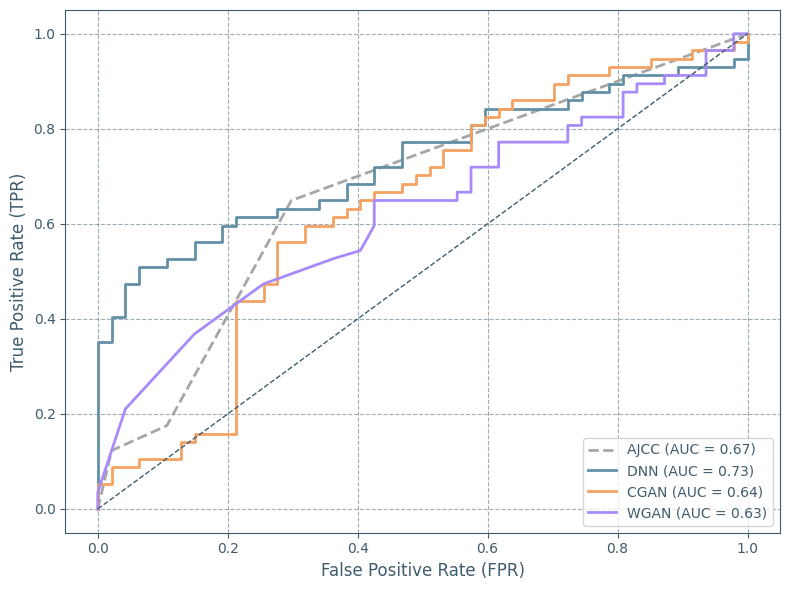

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Define colors
lotline_color = "#3F5C6C"
dnn_color = "#6390A7"
ajcc_color = "#A6A6A6"
import numpy as np

# Simulating example data since actual data is missing


# Compute ROC curves and AUC scores
fpr_cgan, tpr_cgan, _ = roc_curve(df_validation['real_labels'], pred_probs_median_cgan[:, 1])
roc_auc_cgan = auc(fpr_cgan, tpr_cgan)

fpr_wgan, tpr_wgan, _ = roc_curve(df_validation['real_labels'], pred_probs_median_wgan[:, 1])
roc_auc_wgan = auc(fpr_wgan, tpr_wgan)

fpr_model, tpr_model, _ = roc_curve(df_validation['real_labels'], df_validation['yes_disease'])
roc_auc_model = auc(fpr_model, tpr_model)

fpr_staging, tpr_staging, _ = roc_curve(df_validation['real_labels'], df_validation['staging_disease_prob'])
roc_auc_staging = auc(fpr_staging, tpr_staging)

# Define new colors for better contrast
cgan_color = "#F4A261"  # Deep orange for CGAN
wgan_color = "#A78BFA"  # Rich purple for WGAN

# Create the plot
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Set plot spines color
for spine in ax.spines.values():
    spine.set_color(lotline_color)

# Plot ROC curves
plt.plot(fpr_staging, tpr_staging, label=f'AJCC (AUC = {roc_auc_staging:.2f})', lw=2, linestyle='--', color=ajcc_color)
plt.plot(fpr_model, tpr_model, label=f'DNN (AUC = {roc_auc_model:.2f})', lw=2, color=dnn_color)
plt.plot(fpr_cgan, tpr_cgan, label=f'CGAN (AUC = {roc_auc_cgan:.2f})', lw=2, color=cgan_color)
plt.plot(fpr_wgan, tpr_wgan, label=f'WGAN (AUC = {roc_auc_wgan:.2f})', lw=2, color=wgan_color)

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color=lotline_color, linestyle='--', lw=1)

# Axis labels with correct color
plt.xlabel('False Positive Rate (FPR)', fontsize=12, color=lotline_color)
plt.ylabel('True Positive Rate (TPR)', fontsize=12, color=lotline_color)

# Change tick and number colors

ax.tick_params(axis='both', colors=lotline_color)

plt.xticks(color=lotline_color)

plt.yticks(color=lotline_color)



# Grid customization with dashed lines

plt.grid(alpha=0.5, color=lotline_color, linestyle="--")




# Grid customization with dashed lines
plt.grid(alpha=0.5, color=lotline_color, linestyle="--")

# Legend
plt.legend(loc='lower right', fontsize=10, labelcolor=lotline_color)

# Layout adjustments
plt.tight_layout()

# Show the plot
plt.show()


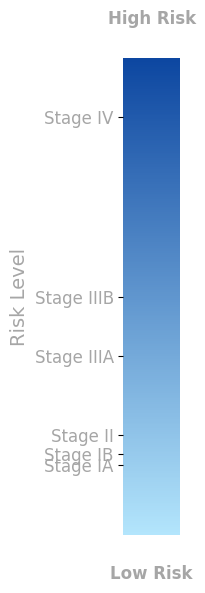

In [136]:
# Define AJCC stages and corresponding OS percentages
ajcc_stages = ["Stage IA", "Stage IB", "Stage II", "Stage IIIA", "Stage IIIB", "Stage IV"]
os_percentages = [85.3, 83.0, 79.0, 62.4, 50.1, 12.4]

from matplotlib.colors import LinearSegmentedColormap



custom_cmap = LinearSegmentedColormap.from_list(

    "custom_cmap", ["#B3E5FC", "#0D47A1"], N=256  # Light blue to dark blue

)

# Convert OS percentages into risk positions (inverted so lower OS is higher risk)
stage_positions = [1 - (os / 100) for os in os_percentages]

# Create the figure
fig, ax = plt.subplots(figsize=(2, 6))



# Display the color gradient

risk_levels = np.linspace(1, 0, 256).reshape(-1, 1)  # Reversed for softest colors at the bottom

ax.imshow(risk_levels, cmap=custom_cmap, aspect='auto', extent=[0, 1, 0, 1])





# Set ticks and labels based on actual OS-based risk positioning
ax.set_yticks(stage_positions)
ax.set_yticklabels(ajcc_stages, fontsize=12, color="#A6A6A6")

# Remove x-axis elements
ax.set_xticks([])
ax.set_xticklabels([])
ax.set_xlabel("")

# Set y-axis label
ax.set_ylabel("Risk Level", fontsize=14, color="#A6A6A6")
# Add "Low Risk" and "High Risk" labels at bottom and top

ax.text(0.5, -.1, "Low Risk", ha='center', va='bottom', fontsize=12, color="#A6A6A6", weight='bold', transform=ax.transAxes)

ax.text(0.5, 1.1, "High Risk", ha='center', va='top', fontsize=12, color="#A6A6A6", weight='bold', transform=ax.transAxes)




# Remove surrounding box for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Show the plot
plt.tight_layout()
plt.show()



In [115]:

# Assuming df is your DataFrame
# Step 1: Filter low-risk cases according to staging
low_risk_staging = df_validation[df_validation['staging_disease_prob'] < 0.5]

# Step 2: Identify actual high-risk cases
actual_high_risk = low_risk_staging[low_risk_staging['real_labels'] == 1]

# Step 3: Find cases where the model predicts correctly
model_correct = actual_high_risk[actual_high_risk['predicted_labels'] == 1]

# Step 4: Display or export the relevant cases
model_correct


,size_a,size_b,size_c,age_admission,male,female,group_B,group_D,group_S,metastasis_no,...,predicted_labels,no_disease,yes_disease,max_size_cm,staging,staging_prob,staging_off,staging_disease_prob,cgan_prob,wgan_prob
1,NaN,NaN,NaN,79.000000,0.0,1.0,0.0,0.0,1.0,1.0,...,1,0.207750,0.743760,NaN,Stage IIIA,0.624,0.376,0.376,0.328516,0.994942
6,NaN,NaN,NaN,68.000000,0.0,1.0,0.0,1.0,0.0,1.0,...,1,0.424543,0.645671,NaN,Stage IIIA,0.624,0.376,0.376,0.454988,0.994942
11,25.000000,19.999998,20.000000,39.000000,1.0,0.0,0.0,1.0,0.0,1.0,...,1,0.482288,0.517400,2.500000,Stage II,0.700,0.300,0.300,0.035844,0.013615
13,NaN,NaN,NaN,50.000000,0.0,1.0,0.0,0.0,1.0,1.0,...,1,0.258444,0.743483,NaN,Stage IIIA,0.624,0.376,0.376,0.687720,0.013614
14,NaN,NaN,NaN,56.000004,0.0,1.0,0.0,0.0,1.0,1.0,...,1,0.199238,0.758961,NaN,Stage IIIA,0.624,0.376,0.376,0.939365,0.994943
15,NaN,NaN,NaN,75.000000,0.0,1.0,0.0,0.0,1.0,1.0,...,1,0.182678,0.773070,NaN,Stage IIIA,0.624,0.376,0.376,0.336185,0.994942
17,NaN,NaN,NaN,71.000000,1.0,0.0,0.0,0.0,1.0,1.0,...,1,0.294521,0.693517,NaN,Stage IIIA,0.624,0.376,0.376,0.942007,0.994943
18,44.999996,35.000000,20.000000,76.000000,1.0,0.0,0.0,0.0,1.0,1.0,...,1,0.235174,0.683764,4.500000,Stage II,0.700,0.300,0.300,0.919399,0.994943
26,NaN,NaN,NaN,77.000000,0.0,1.0,0.0,0.0,1.0,1.0,...,1,0.195286,0.803570,NaN,Stage IIIA,0.624,0.376,0.376,0.937887,0.994943
27,NaN,NaN,NaN,47.000000,0.0,1.0,0.0,0.0,1.0,1.0,...,1,0.316151,0.685258,NaN,Stage IIIA,0.624,0.376,0.376,0.698151,0.013614


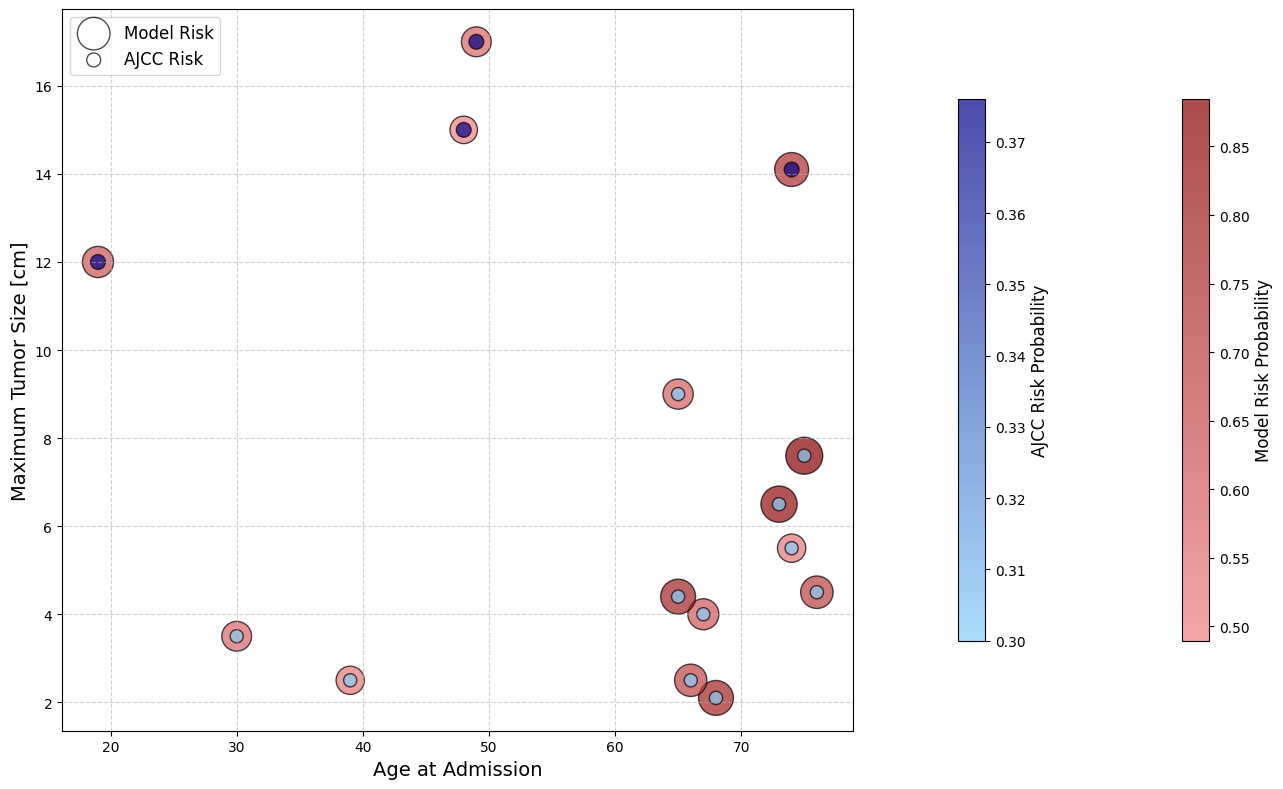

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
reds_cmap = LinearSegmentedColormap.from_list("custom_red", ["lightcoral", "darkred"])
# Custom colormap for AJCC Risk (blue)
blues_cmap = LinearSegmentedColormap.from_list("custom_blue", ["lightskyblue", "darkblue"])

# Normalize point sizes for better differentiation
model_sizes = model_correct['yes_disease'] * 800  # Scale model probabilities for size
ajcc_sizes = model_correct['staging_disease_prob'] * 300  # Scale AJCC probabilities for size

# Plot setup
plt.figure(figsize=(14, 8))

# Plot for Model Risk
model_scatter = plt.scatter(
    x=model_correct['age_admission'], 
    y=model_correct['max_size_cm'], 
    c=model_correct['yes_disease'],  # Color represents your model's risk
    cmap=reds_cmap,
    s=model_sizes,  # Size scaled to model probabilities
    alpha=0.7, 
    edgecolors='k',
    label='Model Risk'
)

# Plot for AJCC Risk
ajcc_scatter = plt.scatter(
    x=model_correct['age_admission'], 
    y=model_correct['max_size_cm'], 
    c=model_correct['staging_disease_prob'],  # Color represents AJCC's risk
    cmap=blues_cmap,  # Custom colormap for AJCC 
    s=ajcc_sizes,  # Size scaled to AJCC probabilities
    alpha=0.7, 
    edgecolors='k',
    label='AJCC Risk'
)

# Add colorbars for each scatter plot
cbar_model = plt.colorbar(model_scatter, ax=plt.gca(), shrink=0.75)
cbar_model.set_label('Model Risk Probability', fontsize=12)

cbar_ajcc = plt.colorbar(ajcc_scatter, ax=plt.gca(), shrink=0.75, pad=0.1)
cbar_ajcc.set_label('AJCC Risk Probability', fontsize=12)

# Plot formatting
# plt.title("Age vs. Tumor Size with Model and AJCC Risk Probabilities", fontsize=16)
plt.xlabel("Age at Admission", fontsize=14)
plt.ylabel("Maximum Tumor Size [cm]", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# Add legend for differentiation
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()

# Show plot
plt.show()



/tmp/ipykernel_12959/536056047.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_correct['max_size_cm_filled'] = model_correct['max_size_cm'].fillna(-1)  # Use -1 to indicate missing size


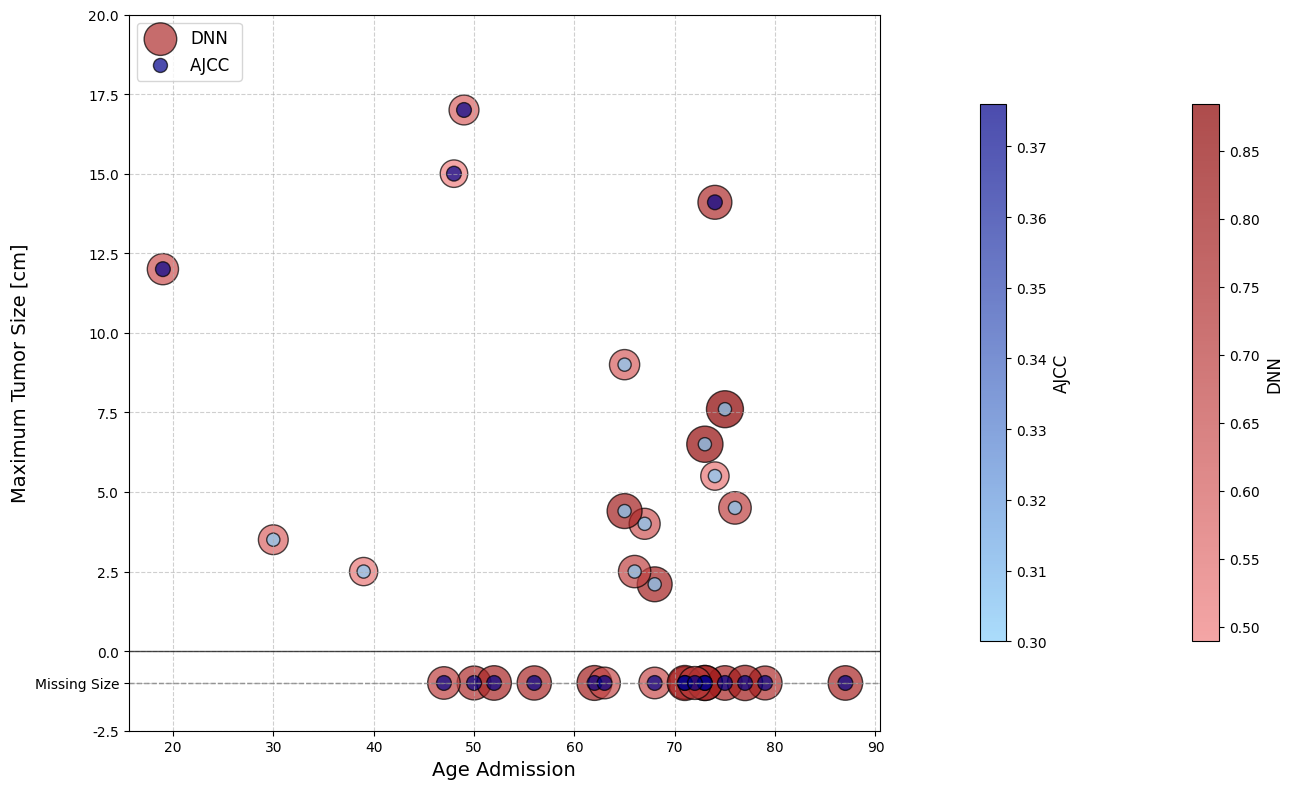

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Custom colormaps for Model and AJCC Risks
reds_cmap = LinearSegmentedColormap.from_list("custom_red", ["lightcoral", "darkred"])
blues_cmap = LinearSegmentedColormap.from_list("custom_blue", ["lightskyblue", "darkblue"])

# Normalize point sizes for better differentiation
model_sizes = model_correct['yes_disease'] * 800  # Scale model probabilities for size
ajcc_sizes = model_correct['staging_disease_prob'] * 300  # Scale AJCC probabilities for size

# Create a new column for visualizing missing size
model_correct['max_size_cm_filled'] = model_correct['max_size_cm'].fillna(-1)  # Use -1 to indicate missing size

# Plot setup
plt.figure(figsize=(14, 8))

# Plot for Model Risk
model_scatter = plt.scatter(
    x=model_correct['age_admission'], 
    y=model_correct['max_size_cm_filled'],  # Use the filled column
    c=model_correct['yes_disease'],  # Color represents your model's risk
    cmap=reds_cmap,
    s=model_sizes,  # Size scaled to model probabilities
    alpha=0.7, 
    edgecolors='k',
    label='DNN'
)

# Plot for AJCC Risk
ajcc_scatter = plt.scatter(
    x=model_correct['age_admission'], 
    y=model_correct['max_size_cm_filled'],  # Use the filled column
    c=model_correct['staging_disease_prob'],  # Color represents AJCC's risk
    cmap=blues_cmap,  # Custom colormap for AJCC 
    s=ajcc_sizes,  # Size scaled to AJCC probabilities
    alpha=0.7, 
    edgecolors='k',
    label='AJCC '
)

# Add colorbars for each scatter plot
cbar_model = plt.colorbar(model_scatter, ax=plt.gca(), shrink=0.75)
cbar_model.set_label('DNN', fontsize=12)

cbar_ajcc = plt.colorbar(ajcc_scatter, ax=plt.gca(), shrink=0.75, pad=0.1)
cbar_ajcc.set_label('AJCC', fontsize=12)
plt.axhline(y=-1, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Add a ticker line at size zero
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.7)

# Highlight missing size cases without adding to legend
plt.axhline(y=-1, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Plot formatting
# plt.title("Age vs. Tumor Size with Model and AJCC Risk Probabilities (Including Missing Size)", fontsize=16)
plt.xlabel("Age Admission", fontsize=14)
plt.ylabel("Maximum Tumor Size [cm]", fontsize=14)
plt.yticks(list(plt.yticks()[0]) + [-1], labels=list(map(str, plt.yticks()[0])) + ["Missing Size"])
plt.grid(True, linestyle='--', alpha=0.6)

# Add legend for differentiation (excluding missing size line)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()

# Show plot
plt.show()



/tmp/ipykernel_12959/2827578092.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_correct['high_risk_prob'] = model_correct['yes_disease'] * 100
/tmp/ipykernel_12959/2827578092.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_correct['ajcc_high_risk_prob'] = model_correct['staging_disease_prob'] * 100


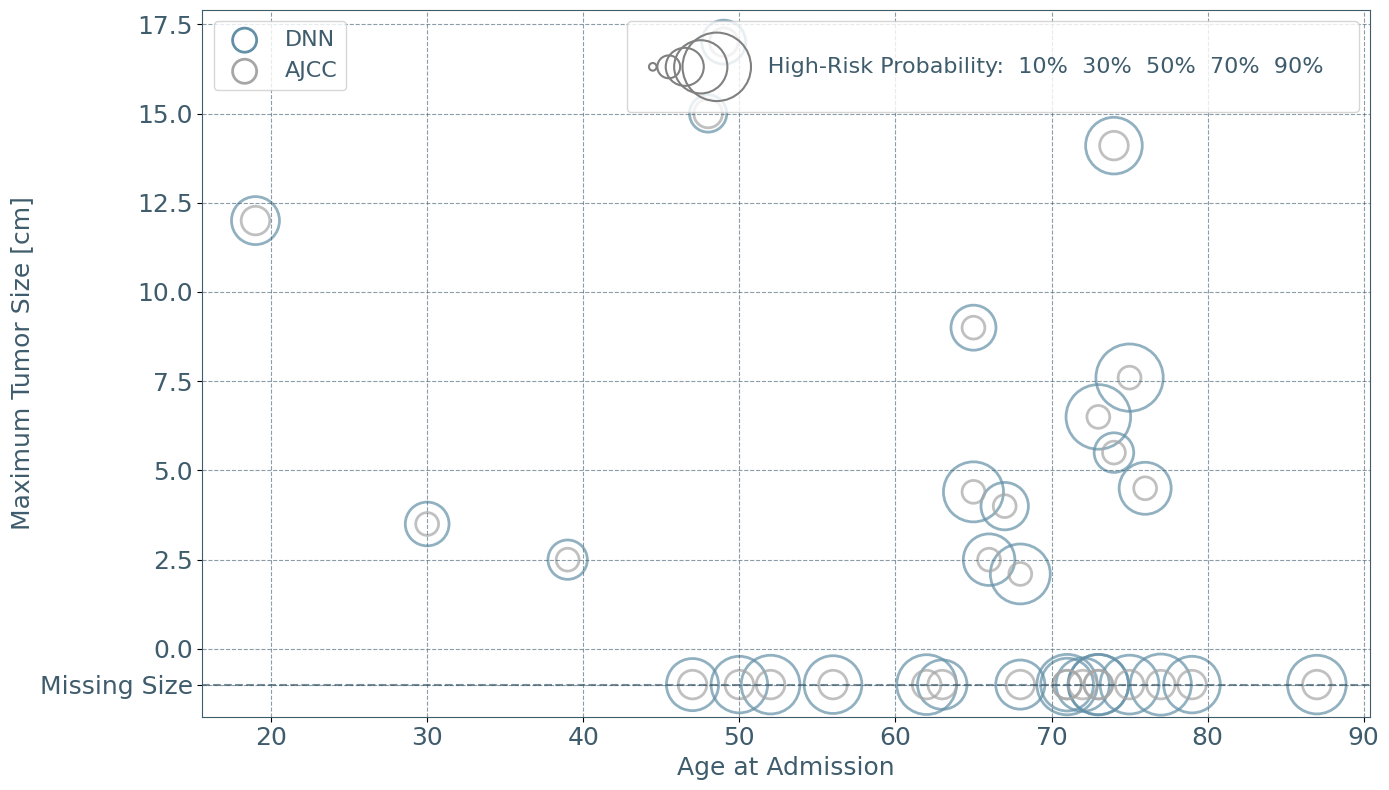

In [118]:
import matplotlib.font_manager as fm

# Define custom colors
lotline_color = "#3F5C6C"
dnn_color = "#6390A7"
ajcc_color = "#A6A6A6"
font_size = 18
# Adjusting the visualization with correct grid color across the entire plot

# Create figure
plt.figure(figsize=(14, 8))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color(lotline_color)
# Convert high-risk probability to percentage for display
model_correct['high_risk_prob'] = model_correct['yes_disease'] * 100  
model_correct['ajcc_high_risk_prob'] = model_correct['staging_disease_prob'] * 100  

# Quadratic scaling for better differentiation
model_sizes = (model_correct['high_risk_prob'] / 100) ** 2 * 3000  
ajcc_sizes = (model_correct['ajcc_high_risk_prob'] / 100) ** 2 * 3000  

# Plot for Model Risk (DNN) - Only edges painted
model_scatter = plt.scatter(
    x=model_correct['age_admission'], 
    y=model_correct['max_size_cm_filled'],
    facecolors='none', 
    edgecolors=dnn_color,  
    s=model_sizes,  
    alpha=0.7, 
    linewidth=2.0,
    label='DNN'
)

# Plot for AJCC Risk - Only edges painted
ajcc_scatter = plt.scatter(
    x=model_correct['age_admission'], 
    y=model_correct['max_size_cm_filled'],
    facecolors='none',  
    edgecolors=ajcc_color,  
    s=ajcc_sizes,  
    alpha=0.7, 
    linewidth=2.0,
    label='AJCC'
)

# Highlight missing size cases with custom color
plt.axhline(y=-1, color=lotline_color, linestyle='--', linewidth=1.5, alpha=0.7, label='Missing Size')

# Formatting
plt.xlabel("Age at Admission", fontsize=font_size, color=lotline_color)
plt.ylabel("Maximum Tumor Size [cm]", fontsize=font_size, color=lotline_color)
plt.yticks(list(plt.yticks()[0]) + [-1], labels=list(map(str, plt.yticks()[0])) + ["Missing Size"], color=lotline_color, fontsize=font_size)
plt.xticks(color=lotline_color, fontsize=font_size)

# Apply grid color to entire plot
plt.grid(True, linestyle='--', alpha=0.6, color=lotline_color) 

# Create a probability scale legend using correct circle sizes (clearly spaced) and high-risk probability in %
legend_percentages = [10, 30, 50, 70, 90]  # High-risk probability in %
legend_labels = [f"{p}%" for p in legend_percentages]

legend_circles = [plt.scatter([], [], s=(p / 100) ** 2 * 3000, facecolors='none', edgecolors="gray", linewidth=1.5) for p in legend_percentages]

# Adjusting legend box to contain all circles correctly
probability_legend = plt.legend(
    [tuple(legend_circles)], 
    ["      High-Risk Probability:  10%  30%  50%  70%  90%"], 
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc='upper right',  fontsize=16, labelcolor=lotline_color,
    bbox_to_anchor=(1, 1),
      borderpad=1.6  # Adjusted to prevent overlap
)
plt.gca().add_artist(probability_legend)

# Add main legend for model differentiation with same-size circles
dnn_legend = plt.scatter([], [], s=300, facecolors='none', edgecolors=dnn_color, linewidth=2.0, label="DNN")
ajcc_legend = plt.scatter([], [], s=300, facecolors='none', edgecolors=ajcc_color, linewidth=2.0, label="AJCC")

plt.legend(handles=[dnn_legend, ajcc_legend], loc='upper left', fontsize=16, labelcolor=lotline_color)

plt.tight_layout()

# Show plot
plt.show()


Accuracy: 0.64


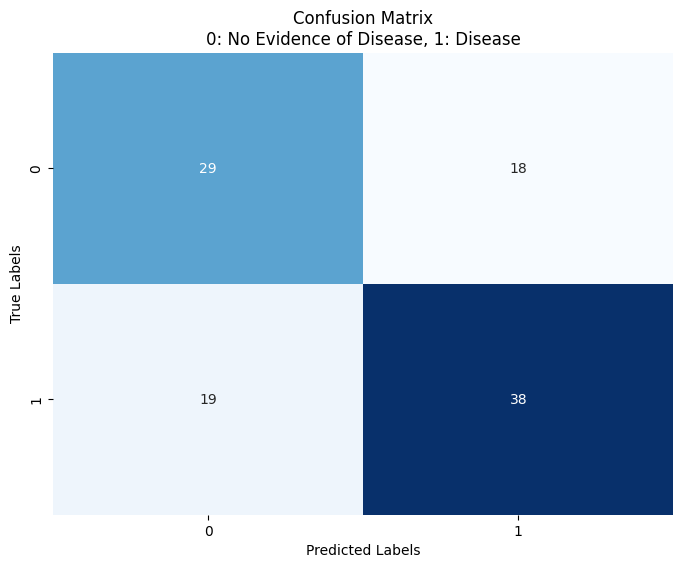

In [119]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt



# Compute confusion matrix
conf_matrix = confusion_matrix(df_validation['real_labels'], df_validation['predicted_labels'])
accuracy = accuracy_score(df_validation['real_labels'], df_validation['predicted_labels'])
print(f'Accuracy: {accuracy:.2f}')
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix\n0: No Evidence of Disease, 1: Disease')
plt.show()

In [120]:
df_validation.head()

,size_a,size_b,size_c,age_admission,male,female,group_B,group_D,group_S,metastasis_no,...,predicted_labels,no_disease,yes_disease,max_size_cm,staging,staging_prob,staging_off,staging_disease_prob,cgan_prob,wgan_prob
0,94.999992,53.0,51.0,55.000004,0.0,1.0,0.0,0.0,1.0,1.0,...,0,0.686204,0.257472,9.499999,Stage II,0.700,0.300,0.300,0.702852,0.013614
1,NaN,NaN,NaN,79.000000,0.0,1.0,0.0,0.0,1.0,1.0,...,1,0.207750,0.743760,NaN,Stage IIIA,0.624,0.376,0.376,0.328516,0.994942
2,NaN,NaN,NaN,83.000000,1.0,0.0,0.0,1.0,0.0,1.0,...,1,0.340332,0.647918,NaN,Stage IIIA,0.624,0.376,0.376,0.052532,0.994942
3,NaN,NaN,NaN,29.000000,0.0,1.0,0.0,0.0,1.0,1.0,...,0,0.717996,0.312211,NaN,Stage IIIA,0.624,0.376,0.376,0.710873,0.013613
4,49.999996,39.0,39.0,35.000000,0.0,1.0,0.0,0.0,1.0,0.0,...,1,0.074883,0.834200,5.000000,Stage IV,0.124,0.876,0.876,0.855520,0.994943


In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Define age intervals including 0-19
age_bins = [0, 20, 40, 60, 80, 100]
age_labels = ['0-19', '20-39', '40-59', '60-79', '80+']
df_validation['age_group'] = pd.cut(df_validation['age_admission'], bins=age_bins, labels=age_labels, right=False)

# Drop rows with NaN in real_labels or predicted_labels for calculation
df_clean = df_validation.dropna(subset=['real_labels', 'predicted_labels'])

# Model-based prediction accuracy by age group
df_clean['correct_model_prediction'] = df_clean['real_labels'] == df_clean['predicted_labels']
model_accuracy = df_clean.groupby('age_group')['correct_model_prediction'].mean() * 100

# Define threshold predictions based on the mode of real_labels in each age group
threshold_conditions = df_clean.groupby('age_group')['real_labels'].agg(lambda x: x.mode()[0])
df_clean['threshold_prediction'] = df'patient_info.age_at_admission',
       'treatment_features.surgery', 'treatment_features.max_dimension',
       'treatment_features.complexity_number',
       'treatment_features.chemotherapy', 'treatment_features.cycle_number',
       'initial_diagnosis.initial_size_a', 'initial_diagnosis.initial_size_b',
       'initial_diagnosis.initial_size_c',
       'treatment_features.radiation_oncology', 'treatment_features.dose',
       'treatment_features.number_fractions', 'treatment_features.ptv_volume',
       'treatment_features.gtv_volume', 'treatment_features.resection',
       'treatment_features.neo_adjuvant',
       'treatment_features.closest_distance',
       'initial_diagnosis.first_anatomic_region_code_grouping_B',
       'initial_diagnosis.first_anatomic_region_code_grouping_D',
       'initial_diagnosis.first_anatomic_region_code_grouping_S',
       'initial_diagnosis.first_diagnosis_malignant_benign_2.0',
       'initial_diagnosis.first_diagnosis_malignant_benign_3.0',
       'initial_diagnosis.metastasis_initial_presentation_exists_original_0.0',
       'initial_diagnosis.metastasis_initial_presentation_exists_original_1.0',
       'patient_info.gender_1.0', 'patient_info.gender_2.0',
       'treatment_features.mib_of_sarcoma_0.0',
       'treatment_features.mib_of_sarcoma_1.0',
       'treatment_features.mib_of_sarcoma_2.0',
       'treatment_features.mib_of_sarcoma_3.0',
       'treatment_features.mib_of_sarcoma_4.0',
       'treatment_features.mib_of_sarcoma_5.0',
       'treatment_features.mib_of_sarcoma_6.0',
       'treatment_features.mib_of_sarcoma_7.0',
       'treatment_features.mib_of_sarcoma_8.0',
       'treatment_features.mib_of_sarcoma_9.0',
       'treatment_features.mib_of_sarcoma_10.0',
       'treatment_features.mib_of_sarcoma_nan',
       'treatment_features.mitotic_0.0', 'treatment_features.mitotic_1.0',
       'treatment_features.mitotic_2.0', 'treatment_features.mitotic_3.0',
       'treatment_features.mitotic_nan', 'treatment_features.necrosis_0.0',
       'treatment_features.necrosis_1.0', 'treatment_features.necrosis_2.0',
       'treatment_features.necrosis_3.0', 'treatment_features.necrosis_4.0',
       'treatment_features.necrosis_6.0', 'treatment_features.necrosis_9.0',
       'treatment_features.necrosis_10.0', 'treatment_features.necrosis_nan',
       'treatment_features.side_1.0', 'treatment_features.side_2.0',
       'treatment_features.side_3.0', 'treatment_features.side_8.0',
       'treatment_features.side_nan', 'treatment_features.substances_nan']_clean['age_group'].map(threshold_conditions)
df_clean['correct_threshold_prediction'] = df_clean['real_labels'] == df_clean['threshold_prediction']
threshold_accuracy = df_clean.groupby('age_group')['correct_threshold_prediction'].mean() * 100

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Bar width
bar_width = 0.35
index = np.arange(len(age_labels))

# Model accuracy bars
bar1 = ax.bar(index, model_accuracy, bar_width, label='Model Prediction Accuracy (%)', color='skyblue')

# Threshold accuracy bars
bar2 = ax.bar(index + bar_width, threshold_accuracy, bar_width, label='Threshold-Based Accuracy (%)', color='orange')

# Labels and titles
ax.set_xlabel('Age Group')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparison of Model Prediction Accuracy and Threshold-Based Accuracy Across Age Groups')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(age_labels)
ax.set_ylim(0, 100)

# Add legend
ax.legend()

plt.show()

SyntaxError: unmatched ']' (2190675037.py, line 60)